### Prediction of Mechanical Properties of H13 Tool Steel on the Basis of Input Parameters used for LPBF Additive Manufacturing

We will be using linear regression technique for predicting the mechanical properties.
 
To start with, let us begin by importing necessary libraries and having an overview of the data



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


Now, we will import our dataset which is stored locally.

In [ ]:
file_path=r"C:\Users\user\Desktop\Explo\augmented_dataset_rounded.xlsx"
df = pd.read_excel(file_path)

We note that we do not have openpyxl installed for reading xlsx files so let us deal with it first.

In [ ]:
file_path=r"C:\Users\user\Desktop\Explo\augmented_dataset_rounded.xlsx"
df = pd.read_excel(file_path)
df.head(5)

,Material,Laser Power (W),Scan Speed(mm/s),Hatch Angle,Hatch Spacing,Laser Energy Density,Temperature(C),Hardness(Hv),Yield Strength,UTS,Ductility,Porosity%
0,H13,400,NaN,45.0,NaN,47.6,NaN,600.0,1223.0,1620.0,4.7,NaN
1,H13 (A3),300,800.0,NaN,0.12,78.1,NaN,NaN,NaN,NaN,NaN,NaN
2,H13,210,700.0,43.7,NaN,79.9,40.0,550.0,1920.0,1962.0,8.2,NaN
3,MS1-H13,285,960.0,NaN,0.11,NaN,NaN,423.0,NaN,1126.0,NaN,NaN
4,H13,280,980.0,NaN,0.12,59.5,NaN,NaN,NaN,NaN,NaN,98.6


We see that we have now successfully imported out dataset. To clean the data, we also need to deal with missing or "NaN" values.

In [5]:
df.isnull().sum()

Material                 0
Laser Power (W)          0
Scan Speed(mm/s)         3
Hatch Angle             16
Hatch Spacing            6
Laser Energy Density    31
Temperature(C)          18
Hardness(Hv)            16
Yield Strength          19
UTS                     17
Ductility               24
Porosity%               21
dtype: int64

We see that we have a lot of missing data for laser energy density values so it will be better to ignore for training.

For Hatch Angle and Hatch spacing, we can deal with missing values by replacing NaN with 67 degrees and mean of values respectively.

In [ ]:
df['Hatch Spacing'].fillna(df['Hatch Spacing'].mean(), inplace=True)
df['Hatch Spacing'].isnull().sum()
df['Hatch Spacing'].head(10)

In [ ]:
prepdf = df.drop('Hatch Angle',axis=1)
df['Scan Speed(mm/s)'].fillna(df['Scan Speed(mm/s)'].mean(), inplace=True)
df['Hardness(Hv)'].fillna(df['Hardness(Hv)'].mean(), inplace=True)
df['Yield Strength '].fillna(df['Yield Strength '].mean(), inplace=True)
df['UTS'].fillna(df['UTS'].mean(), inplace=True)
df['Ductility'].fillna(df['Ductility'].mean(), inplace=True)
df['Porosity%'].fillna(df['Porosity%'].mean(), inplace=True)

In [8]:
corr_df = df.drop('Material',axis=1)
corr_df.corr()

,Laser Power (W),Scan Speed(mm/s),Hatch Angle,Hatch Spacing,Laser Energy Density,Temperature(C),Hardness(Hv),Yield Strength,UTS,Ductility,Porosity%
Laser Power (W),1.000000,0.323177,-0.280651,0.517239,-0.345259,0.065959,-0.025464,-0.310388,-0.389613,-0.220304,-0.045821
Scan Speed(mm/s),0.323177,1.000000,-0.018490,0.037311,-0.707913,-0.013258,0.032796,-0.387057,-0.412156,-0.011525,0.030776
Hatch Angle,-0.280651,-0.018490,1.000000,-0.147373,-0.811103,0.613854,0.315403,-0.146409,0.572876,0.023517,-0.072654
Hatch Spacing,0.517239,0.037311,-0.147373,1.000000,0.373703,-0.053685,-0.167838,-0.012517,-0.284287,0.040482,-0.048382
Laser Energy Density,-0.345259,-0.707913,-0.811103,0.373703,1.000000,NaN,-0.445352,0.482556,0.689987,0.717743,0.357301
Temperature(C),0.065959,-0.013258,0.613854,-0.053685,NaN,1.000000,0.656905,-0.051103,0.123432,-0.534707,-0.150748
Hardness(Hv),-0.025464,0.032796,0.315403,-0.167838,-0.445352,0.656905,1.000000,0.138065,0.549377,-0.396146,0.005585
Yield Strength,-0.310388,-0.387057,-0.146409,-0.012517,0.482556,-0.051103,0.138065,1.000000,0.177397,-0.106393,0.106104
UTS,-0.389613,-0.412156,0.572876,-0.284287,0.689987,0.123432,0.549377,0.177397,1.000000,0.090848,-0.003062
Ductility,-0.220304,-0.011525,0.023517,0.040482,0.717743,-0.534707,-0.396146,-0.106393,0.090848,1.000000,0.182313


<Axes: >

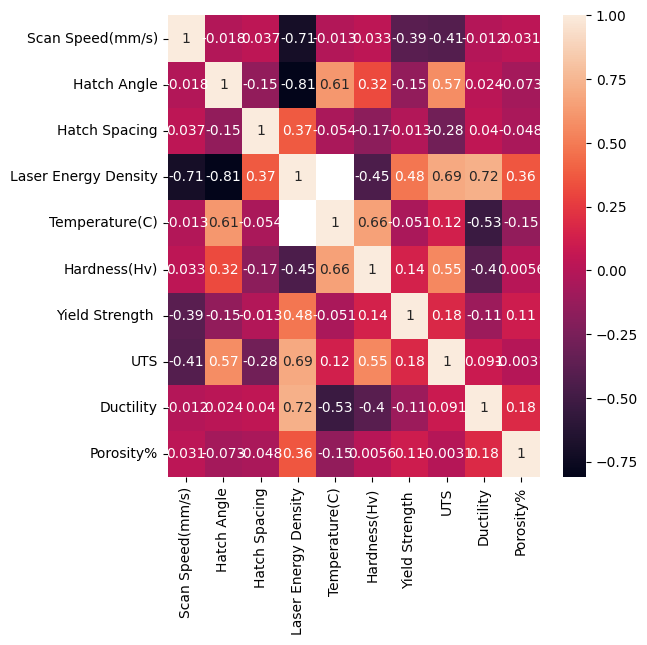

In [9]:
plt.figure(figsize=(6,6))
sns.heatmap(df.select_dtypes(include = 'float64').corr(), annot = True)

Now, we split our dataset into training and test subsets.

In [10]:
x=df[['Laser Power (W)','Scan Speed(mm/s)','Hatch Spacing',]]
y=df[['Hardness(Hv)','Yield Strength ','UTS',"Ductility",'Porosity%']]


In [11]:
x_train, x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

As the preparation of our train and test datasets is done, we can train the model and predict the properties.

In [12]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)
y_pred=regressor.predict(x_test)

We will now test this model on the test set and evaluate its accuracy

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = regressor.predict(x_test)
y_test = np.array(y_test)
y_pred = np.array(y_pred)

columns = ["Hardness(Hv)", "Yield Strength ", "UTS", "Ductility", "Porosity%"]

for i, col in enumerate(columns):
    y_true_col = y_test[:, i]
    y_pred_col = y_pred[:, i]

    mae = mean_absolute_error(y_true_col, y_pred_col)
    rmse = np.sqrt(mean_squared_error(y_true_col, y_pred_col))

    print(f"{col}:")
    print(f"  MAE      : {mae:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print()

Hardness(Hv):
  MAE      : 49.5033
  RMSE     : 66.1146

Yield Strength :
  MAE      : 184.7012
  RMSE     : 252.1100

UTS:
  MAE      : 301.9108
  RMSE     : 349.5755

Ductility:
  MAE      : 1.4401
  RMSE     : 1.8454

Porosity%:
  MAE      : 0.1547
  RMSE     : 0.4087



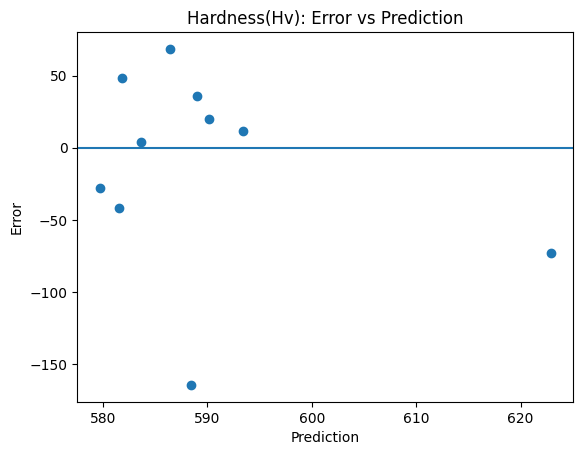

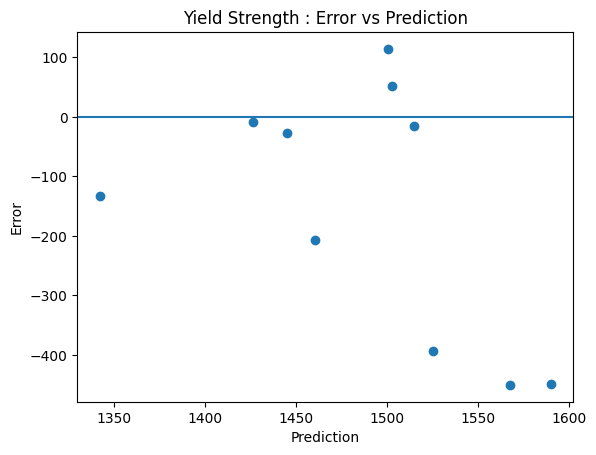

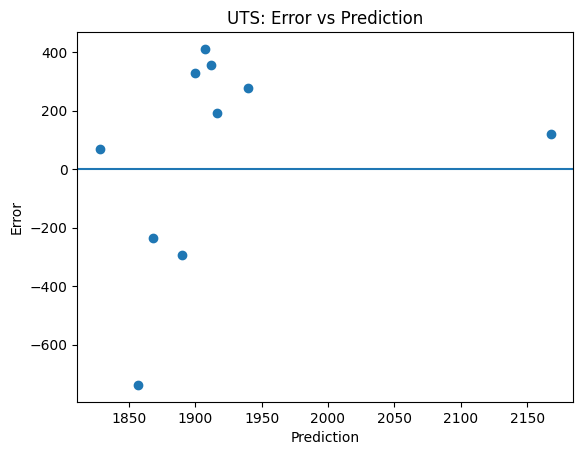

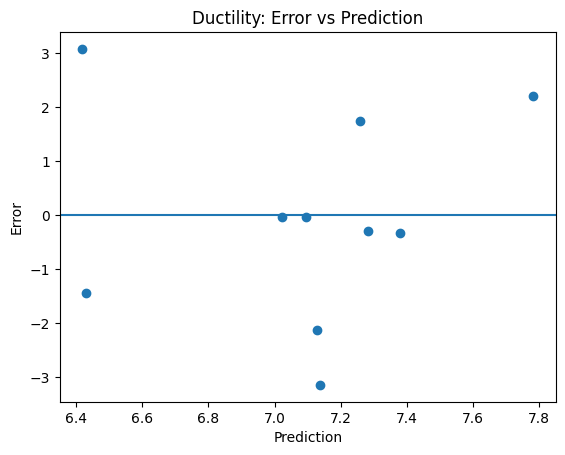

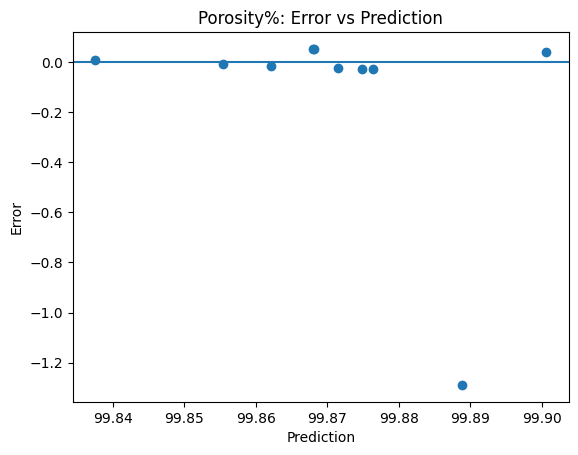

In [14]:
for i, col in enumerate(columns):
    error = y_test[:, i] - y_pred[:, i]

    plt.figure()
    plt.xlabel("Prediction")
    plt.ylabel("Error")
    plt.scatter(y_pred[:, i], error)
    plt.axhline(0)
    plt.title(f"{col}: Error vs Prediction")
    plt.show()